In [1]:
import numpy as np

file_path = "C:/1_Workspace/4_Nam_4/2_HocKy_252/1_Do_An_Chuyen_Nganh/Urban-Traffic-Links/data/processed/model_ready_data_20260213_180132/model_ready_data_20260213_180132_20260213_180132.npz"

data = np.load(file_path, allow_pickle=True)

print("Keys in file:")
print(data.files)

Keys in file:
['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'segment_ids', 'feature_names', '_metadata']


In [2]:
for key in data.files:
    arr = data[key]
    print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")

X_train: shape=(90, 12, 497, 40), dtype=float32
y_train: shape=(90, 12, 497, 40), dtype=float32
X_val: shape=(19, 12, 497, 40), dtype=float32
y_val: shape=(19, 12, 497, 40), dtype=float32
X_test: shape=(20, 12, 497, 40), dtype=float32
y_test: shape=(20, 12, 497, 40), dtype=float32
segment_ids: shape=(497,), dtype=int64
feature_names: shape=(40,), dtype=<U22
_metadata: shape=(1,), dtype=<U245


In [3]:
def check_stats(name, arr):
    print(f"\n{name}")
    print("  Mean:", np.mean(arr))
    print("  Std :", np.std(arr))
    print("  Min :", np.min(arr))
    print("  Max :", np.max(arr))
    
for key in data.files:
    arr = data[key]
    if np.issubdtype(arr.dtype, np.number):
        check_stats(key, arr)


X_train
  Mean: 0.05738365
  Std : 0.951205
  Min : -12.558049
  Max : 15.583741

y_train
  Mean: 0.060808282
  Std : 0.94202113
  Min : -12.558049
  Max : 15.583741

X_val
  Mean: 0.09125966
  Std : 0.8875493
  Min : -12.558049
  Max : 12.601372

y_val
  Mean: 0.060377162
  Std : 0.87551075
  Min : -8.096937
  Max : 14.552855

X_test
  Mean: 0.037923627
  Std : 0.89996564
  Min : -10.490637
  Max : 16.441957

y_test
  Mean: 0.02114459
  Std : 0.9778606
  Min : -10.490637
  Max : 16.441957

segment_ids
  Mean: 6274293629389.224
  Std : 15842840871605.533
  Min : -17040035609700
  Max : 17040035609700


In [4]:
X_train = data["X_train"]
y_train = data["y_train"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nExpected format:")
print("(samples, seq_len, nodes, features)")

X_train shape: (90, 12, 497, 40)
y_train shape: (90, 12, 497, 40)

Expected format:
(samples, seq_len, nodes, features)


In [5]:
X_train = np.stack(X_train)
y_train = np.stack(y_train)

print(X_train.dtype)
print(type(X_train[0]))
print(type(X_train[0][0]))

float32
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [6]:
def check_nan_inf(name, arr):
    print(f"\n{name}")
    print("  dtype:", arr.dtype)
    
    if np.issubdtype(arr.dtype, np.number):
        print("  NaN count:", np.isnan(arr).sum())
        print("  Inf count:", np.isinf(arr).sum())
    else:
        print("  ⚠ Non-numeric array, skipping")

for key in data.files:
    check_nan_inf(key, data[key])


X_train
  dtype: float32
  NaN count: 0
  Inf count: 0

y_train
  dtype: float32
  NaN count: 0
  Inf count: 0

X_val
  dtype: float32
  NaN count: 0
  Inf count: 0

y_val
  dtype: float32
  NaN count: 0
  Inf count: 0

X_test
  dtype: float32
  NaN count: 0
  Inf count: 0

y_test
  dtype: float32
  NaN count: 0
  Inf count: 0

segment_ids
  dtype: int64
  NaN count: 0
  Inf count: 0

feature_names
  dtype: <U22
  ⚠ Non-numeric array, skipping

_metadata
  dtype: <U245
  ⚠ Non-numeric array, skipping


In [7]:
sample_id = 0

print("First sample input shape:", X_train[sample_id].shape)
print("First sample target shape:", y_train[sample_id].shape)

First sample input shape: (12, 497, 40)
First sample target shape: (12, 497, 40)


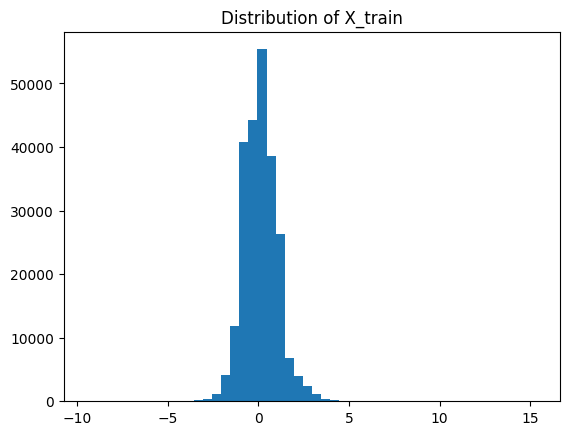

In [8]:
import matplotlib.pyplot as plt

plt.hist(X_train[0].flatten(), bins=50)
plt.title("Distribution of X_train")
plt.show()

In [9]:
n_train = len(data["X_train"])
n_val = len(data["X_val"])
n_test = len(data["X_test"])

total = n_train + n_val + n_test

print("Train %:", n_train / total)
print("Val %  :", n_val / total)
print("Test % :", n_test / total)

Train %: 0.6976744186046512
Val %  : 0.14728682170542637
Test % : 0.15503875968992248


In [10]:
node_variance = np.var(X_train, axis=(0,1,3))  # variance per node

print("Node variance shape:", node_variance.shape)
print("Mean node variance:", node_variance.mean())

Node variance shape: (497,)
Mean node variance: 0.86983734


In [11]:
print("X_train overall std:", np.std(X_train))
print("y_train overall std:", np.std(y_train))

X_train overall std: 0.951205
y_train overall std: 0.94202113
